In [1]:
import MDAnalysis as mda
import numpy as np
import re
import matplotlib.pyplot as plt
import pandas as pd
from MDAnalysis.lib.nsgrid import FastNS
from MDAnalysis.lib import mdamath 
from collections import defaultdict
from scipy.spatial import cKDTree
import math
import os
import matplotlib.pyplot as plt

lammps_data = 'lammps.data'
trajectory_file = 'traj.lammpstrj'
u = mda.Universe(lammps_data, trajectory_file, format='LAMMPSDUMP')


/home/user/anaconda3/lib/python3.12/site-packages/MDAnalysis/coordinates/LAMMPS.py:749: UserWarning: Reader has no dt information, set to 1.0 ps
  ts.data["time"] = step_num * ts.dt


In [2]:

total_chains = 600                                                                
polymer_typeA = 1                                       
polymer_typeB = 2 
receptor_typeC = 3                                       
receptor_typeD = 4

num_bins = 50
max_distance = 50                                                          
bins = np.linspace(0, max_distance, num_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

z_slab = 115.0                                                              
buffer = 0.0   
                        
x_min, x_max = -40, 40
y_min, y_max = -40, 40
z_min, z_max = 32.2, 34.8


In [3]:
def any_common_elements(list1, list2):
    set1 = set(list1)
    for element in set1:
        if element in list2:
            return True
    return False

def partner_array(resid_interest, cutoff, universe):
    array_partner = [resid_interest]
    atom_list = universe.select_atoms(f"around {cutoff:.2f} (resid {resid_interest})")
    for atom in atom_list:
        array_partner.append(atom.resid)
    return list(set(array_partner))

def max_clu(u, total_chains):
    partners_list = [partner_array(ele, 3.0, u) for ele in range(1, total_chains + 1)]
    max_length, max_list = 0, []
    for lst in partners_list:
        if len(lst) > max_length:
            max_length = len(lst)
            max_list = lst
    chain_in_cluster = max_list
    for chains in range(total_chains):
        if any_common_elements(chain_in_cluster, partners_list[chains]):
            chain_in_cluster += partners_list[chains]
            chain_in_cluster = list(set(chain_in_cluster))
    return chain_in_cluster

def is_chain_inside_box(chain, box, buffer=0.):
    for atom in chain.atoms:
        x, y, z = atom.position
        if not (buffer < x < box[0] - buffer and buffer < y < box[1] - buffer and buffer < z < box[2] - buffer):
            return False
    return True


Frame 0: largest receptor cluster = 12 atoms, fraction = 0.059
Frame 1: largest receptor cluster = 34 atoms, fraction = 0.167
Frame 2: largest receptor cluster = 48 atoms, fraction = 0.235
Frame 3: largest receptor cluster = 65 atoms, fraction = 0.319
Frame 4: largest receptor cluster = 93 atoms, fraction = 0.456
Frame 5: largest receptor cluster = 105 atoms, fraction = 0.515
Frame 6: largest receptor cluster = 111 atoms, fraction = 0.544
Frame 7: largest receptor cluster = 121 atoms, fraction = 0.593
Frame 8: largest receptor cluster = 129 atoms, fraction = 0.632
Frame 9: largest receptor cluster = 150 atoms, fraction = 0.735
Frame 10: largest receptor cluster = 156 atoms, fraction = 0.765
Frame 11: largest receptor cluster = 162 atoms, fraction = 0.794
Frame 12: largest receptor cluster = 164 atoms, fraction = 0.804
Frame 13: largest receptor cluster = 157 atoms, fraction = 0.770
Frame 14: largest receptor cluster = 169 atoms, fraction = 0.828
Frame 15: largest receptor cluster = 175

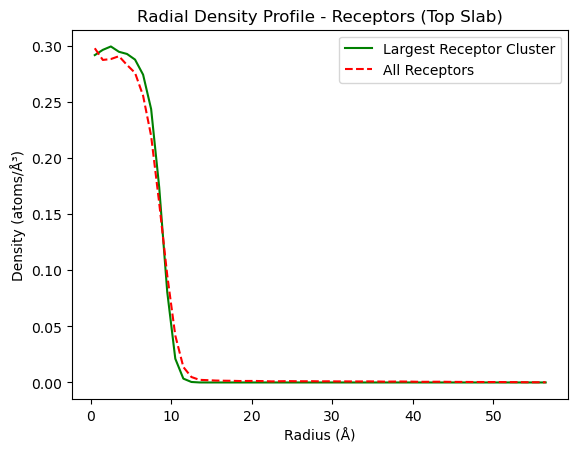

In [4]:
output_frame_csv = 'receptorD_radial_density.csv'
output_density_csv = 'receptorD_radial_density_table.csv'
output_plot = 'receptorD_radial_density.png'

receptor_typeD = 4
cutoff = 2.5
bin_width = 1.0
max_radius = 40.0 * math.sqrt(2)
slab_thickness = 2.6

u = mda.Universe(lammps_data, trajectory_file, format='LAMMPSDUMP')

class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0] * n
    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb:
            return
        if self.rank[ra] < self.rank[rb]:
            self.parent[ra] = rb
        else:
            self.parent[rb] = ra
            if self.rank[ra] == self.rank[rb]:
                self.rank[ra] += 1

def get_cell_index(pos, cell_size, box):
    return tuple((pos // cell_size).astype(int))

bins = np.arange(0, max_radius + bin_width, bin_width)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
shell_volumes = np.pi * slab_thickness * (bins[1:]**2 - bins[:-1]**2)

radial_density_cluster = np.zeros(len(shell_volumes))
radial_density_all = np.zeros(len(shell_volumes))
valid_frames = 0
frame_results = []

for ts in u.trajectory:
    Lz = ts.dimensions[2]
    receptors = u.select_atoms(f"type {receptor_typeD} and prop z>{Lz - slab_thickness}")
    total_receptors = len(receptors)
    if total_receptors == 0:
        continue

    receptors.wrap(compound='fragments')
    positions = receptors.positions
    box = ts.dimensions[:3]
    cell_size = cutoff
    cell_dict = defaultdict(list)
    for i, pos in enumerate(positions):
        cell = get_cell_index(pos, cell_size, box)
        cell_dict[cell].append(i)

    neighbor_offsets = [(dx, dy, dz) for dx in [-1, 0, 1] for dy in [-1, 0, 1] for dz in [-1, 0, 1]]
    pairs = []
    for cell, atom_ids in cell_dict.items():
        for dx, dy, dz in neighbor_offsets:
            neighbor_cell = (
                (cell[0] + dx) % int(box[0] / cell_size),
                (cell[1] + dy) % int(box[1] / cell_size),
                (cell[2] + dz) % int(box[2] / cell_size)
            )
            for i in atom_ids:
                for j in cell_dict.get(neighbor_cell, []):
                    if j <= i:
                        continue
                    diff = positions[i] - positions[j]
                    diff -= box * np.round(diff / box)
                    if np.dot(diff, diff) <= cutoff**2:
                        pairs.append((i, j))

    uf = UnionFind(total_receptors)
    for i, j in pairs:
        uf.union(i, j)

    groups = defaultdict(list)
    for i in range(total_receptors):
        groups[uf.find(i)].append(i)

    largest_cluster = max(groups.values(), key=len)
    fraction = len(largest_cluster) / total_receptors
    print(f"Frame {ts.frame}: largest receptor cluster = {len(largest_cluster)} atoms, fraction = {fraction:.3f}")

    frame_results.append([ts.frame, total_receptors, len(largest_cluster), fraction])

    cluster_positions = positions[largest_cluster]
    ref_com_cluster = cluster_positions.mean(axis=0)
    distances_cluster = np.linalg.norm(cluster_positions[:, :2] - ref_com_cluster[:2], axis=1)
    hist_cluster, _ = np.histogram(distances_cluster, bins=bins)
    radial_density_cluster += hist_cluster

    ref_com_all = receptors.center_of_mass()
    distances_all = np.linalg.norm(positions[:, :2] - ref_com_all[:2], axis=1)
    hist_all, _ = np.histogram(distances_all, bins=bins)
    radial_density_all += hist_all

    valid_frames += 1

df_frame = pd.DataFrame(frame_results, columns=["Frame", "TotalReceptors", "LargestClusterSize", "Fraction"])
df_frame.to_csv(output_frame_csv, index=False)

radial_density_cluster /= (valid_frames * shell_volumes)
radial_density_all /= (valid_frames * shell_volumes)

density_table = pd.DataFrame({
    "Radius (Å)": bin_centers,
    "Cluster Density (atoms/Å³)": radial_density_cluster,
    "All Receptors Density (atoms/Å³)": radial_density_all
})
density_table.to_csv(output_density_csv, index=False)

plt.plot(bin_centers, radial_density_cluster, label="Largest Receptor Cluster", color='g')
plt.plot(bin_centers, radial_density_all, label="All Receptors", color='r', linestyle='--')
plt.xlabel("Radius (Å)")
plt.ylabel("Density (atoms/Å³)")
plt.legend()
plt.title("Radial Density Profile - Receptors (Top Slab)")
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
print(df_frame.columns.tolist())
